# Experiment 3.0.7 — Calibrated Online Early Decision

Analysis-only notebook for fixed-time curves and the accuracy-latency / accuracy-computation frontiers.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks/artifacts/experiment_3_0_7_online_early_decision/calibrated_commit_v1'
ROOT

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_3_0_7_online_early_decision/calibrated_commit_v1')

In [2]:
summary = pd.read_csv(ROOT / 'experiment_3_0_7_policy_summary.csv')
policies = pd.read_csv(ROOT / 'experiment_3_0_7_policy_results.csv')
curves = pd.read_csv(ROOT / 'experiment_3_0_7_fixed_time_curves.csv')
calibration = pd.read_csv(ROOT / 'experiment_3_0_7_calibration.csv')
selection = pd.read_csv(ROOT / 'experiment_3_0_7_validation_selection.csv')
with (ROOT / 'selected_operating_point.json').open() as f:
    selected = json.load(f)
display(summary)
display(calibration)
display(selection.head())
selected

,threshold,stability_m,persistence_ms,mean_balanced_accuracy,sd_balanced_accuracy,mean_macro_f1,mean_latency_ms,median_latency_ms,mean_early_exit_coverage,mean_forced_decision_rate,mean_premature_wrong_rate,mean_spike_activity_cost,mean_synops_proxy
0,0.50,1,0.0,0.577711,0.025271,0.564491,1114.083904,1091.145833,0.447489,0.552511,0.109589,2707.500000,86875.461187
1,0.50,2,250.0,0.598490,0.026114,0.584890,1212.685502,1239.583333,0.230594,0.769406,0.041096,3089.433790,97711.013699
2,0.50,3,500.0,0.611585,0.032103,0.597811,1265.553653,1263.020833,0.107306,0.892694,0.015982,3300.317352,103642.164384
3,0.60,1,0.0,0.601268,0.035616,0.588055,1181.899258,1210.937500,0.301370,0.698630,0.043379,2969.611872,94415.561644
4,0.60,2,250.0,0.611585,0.032103,0.597811,1246.682363,1252.604167,0.168950,0.831050,0.018265,3223.593607,101352.785388
5,0.60,3,500.0,0.611585,0.032103,0.597811,1278.431792,1278.645833,0.059361,0.940639,0.009132,3348.356164,104834.648402
6,0.70,1,0.0,0.611585,0.032103,0.597811,1224.564783,1250.000000,0.210046,0.789954,0.015982,3134.940639,99121.534247
7,0.70,2,250.0,0.614363,0.027696,0.600180,1268.336187,1270.833333,0.118721,0.881279,0.009132,3310.963470,103942.328767
8,0.70,3,500.0,0.616347,0.028169,0.601813,1287.564212,1296.875000,0.029680,0.970320,0.002283,3383.847032,105804.520548
9,0.80,1,0.0,0.616347,0.028169,0.601813,1254.316495,1252.604167,0.134703,0.865297,0.002283,3254.061644,102479.552511


,seed,decoder,source_objective,temperature,validation_calibration_nll
0,11,prefix250_weighted,timestep_ce,1.090184,1.841930
1,23,prefix250_weighted,timestep_ce,1.122018,1.848905
2,101,prefix250_weighted,timestep_ce,1.122018,1.843941


,threshold,stability_m,mean_balanced_accuracy,mean_latency_ms,mean_forced_decision_rate
0,0.7,2,0.548345,1379.464286,0.891534
1,0.6,3,0.548345,1392.154431,0.910053
2,0.8,2,0.548345,1394.675926,0.939153
3,0.9,1,0.548345,1395.171958,0.944444
4,0.7,3,0.548345,1400.173611,0.944444


{'experiment_id': 'experiment_3_0_7_online_early_decision',
 'mean_validation_balanced_accuracy': 0.5483445566778901,
 'mean_validation_latency_ms': 1379.4642857142856,
 'protocol_version': 'calibrated_commit_v1',
 'selection_rule': 'maximize mean validation BA, then minimize mean decision latency',
 'selection_split': 'validation',
 'stability_m': 2,
 'threshold': 0.7}

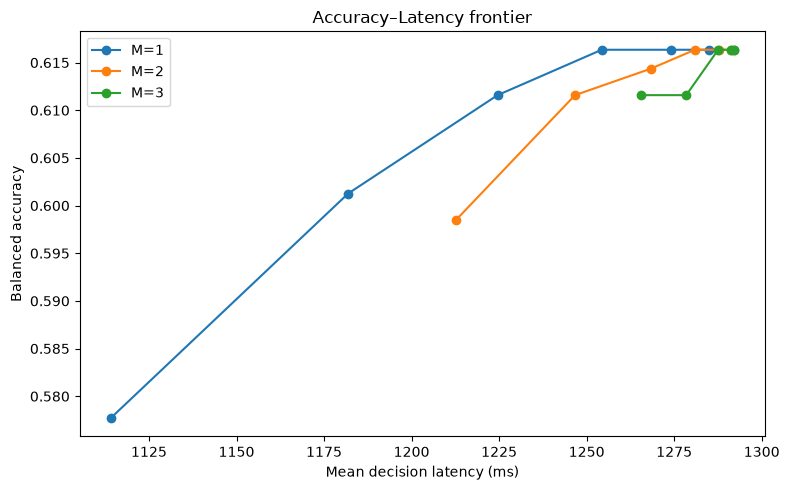

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for m, group in summary.groupby('stability_m'):
    ordered = group.sort_values('mean_latency_ms')
    ax.plot(ordered['mean_latency_ms'], ordered['mean_balanced_accuracy'], marker='o', label=f'M={m}')
ax.set_xlabel('Mean decision latency (ms)')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Accuracy–Latency frontier')
ax.legend()
plt.tight_layout()
plt.show()

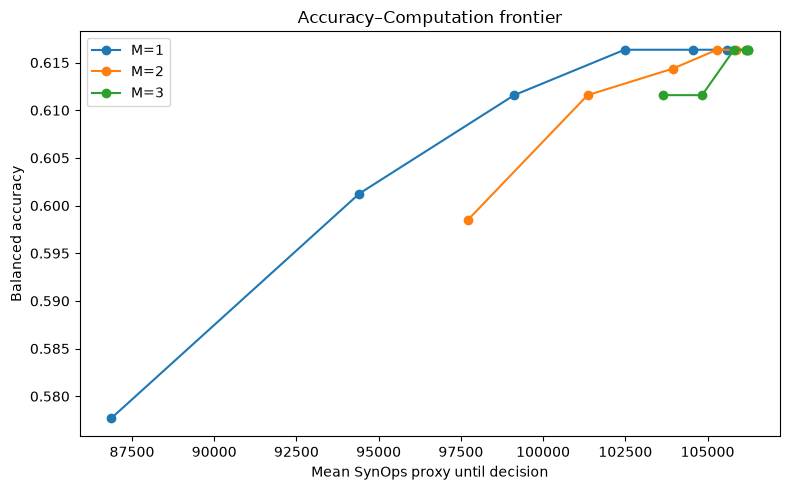

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for m, group in summary.groupby('stability_m'):
    ordered = group.sort_values('mean_synops_proxy')
    ax.plot(ordered['mean_synops_proxy'], ordered['mean_balanced_accuracy'], marker='o', label=f'M={m}')
ax.set_xlabel('Mean SynOps proxy until decision')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Accuracy–Computation frontier')
ax.legend()
plt.tight_layout()
plt.show()